# Similarity Error (SE) Evaluation for xLSTM

This notebook measures the Similarity Error (SE) between real MIDI sequences (validation set) and xLSTM generated MIDI sequences. It uses the metric defined in `evaluation/se_eval_midi_dirs.py`.

In [1]:
# Setup paths
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("/scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen")
EVAL_DIR = PROJECT_ROOT / "evaluation"

# Add evaluation directory to sys.path to import metrics
if str(EVAL_DIR) not in sys.path:
    sys.path.append(str(EVAL_DIR))

print(f"Added {EVAL_DIR} to sys.path")

Added /scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen/evaluation to sys.path


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm
import miditoolkit

# Import from the evaluation script
try:
    from se_eval_midi_dirs import compute_bar_pitch_features, cosine_sim, similarity_curve, similarity_error, list_midis
except ImportError as e:
    print(f"Error importing modules: {e}")
    pass

## Configuration

In [3]:
# Data Directories
VALID_SPLIT_FILE = PROJECT_ROOT / "data/lmd_preprocessed/valid.txt"
MIDI_DATA_DIR = PROJECT_ROOT / "data/lmd_preprocessed/midi"

# Generated MIDI Directory
GEN_DIR = PROJECT_ROOT / "notebooks/xLSTM-2/generated_batch_20260208_041715-xlstm_lmd_512d_2048ctx_12b-checkpoint-84000"

# Evaluation Parameters
T_BARS = 40        # Maximum bar lag to compute similarity
MAX_BARS = 256     # Max bars to read per file

# Output File
# Note: Change this path if you don't have write permissions
OUTPUT_FILE = PROJECT_ROOT / "evaluation/se_results_xlstm_84000.json"

print(f"Validation Split: {VALID_SPLIT_FILE}")
print(f"Real MIDI Dir:    {MIDI_DATA_DIR}")
print(f"Gen MIDI Dir:     {GEN_DIR}")

Validation Split: /scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen/data/lmd_preprocessed/valid.txt
Real MIDI Dir:    /scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen/data/lmd_preprocessed/midi
Gen MIDI Dir:     /scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen/notebooks/xLSTM-2/generated_batch_20260208_041715-xlstm_lmd_512d_2048ctx_12b-checkpoint-84000


## Data Loading Helpers

In [4]:
def get_real_midis(valid_split_file, midi_data_dir):
    """Reads validation filenames and returns list of full paths."""
    real_midis = []
    if not valid_split_file.exists():
        print(f"Error: Validation split file not found at {valid_split_file}")
        return []
    
    with open(valid_split_file, "r") as f:
        for line in f:
            filename = line.strip()
            if filename:
                full_path = midi_data_dir / filename
                
                # Fallback check if extension missing
                if not full_path.exists() and not full_path.suffix:
                     full_path = full_path.with_suffix(".mid")
                
                if full_path.exists():
                    real_midis.append(full_path)
    
    print(f"Found {len(real_midis)} validation MIDI files.")
    return real_midis

def get_gen_midis(gen_dir):
    """List MIDI files in generated directory."""
    return list_midis(gen_dir)

In [5]:
# Load file lists
real_files = get_real_midis(VALID_SPLIT_FILE, MIDI_DATA_DIR)[:80] # Limit to 80
gen_files = get_gen_midis(GEN_DIR)

print(f"Real files count: {len(real_files)}")
print(f"Gen files count:  {len(gen_files)}")

Found 2994 validation MIDI files.
Real files count: 80
Gen files count:  80


## Similarity Computation

In [6]:
# Compute Similarity Curves
print("Computing Self-Similarity Curve for Real Data...")
L_real = similarity_curve(real_files, T=T_BARS, max_bars=MAX_BARS)

print("Computing Self-Similarity Curve for Generated Data...")
L_gen = similarity_curve(gen_files, T=T_BARS, max_bars=MAX_BARS)

Computing Self-Similarity Curve for Real Data...


Computing Self-Similarity Curve for Generated Data...


In [7]:
# Compute Error
se_score = similarity_error(L_real, L_gen)

print("="*40)
print(f"Similarity Error (SE): {se_score:.6f}")
print("="*40)

Similarity Error (SE): 0.047189


## Visualization

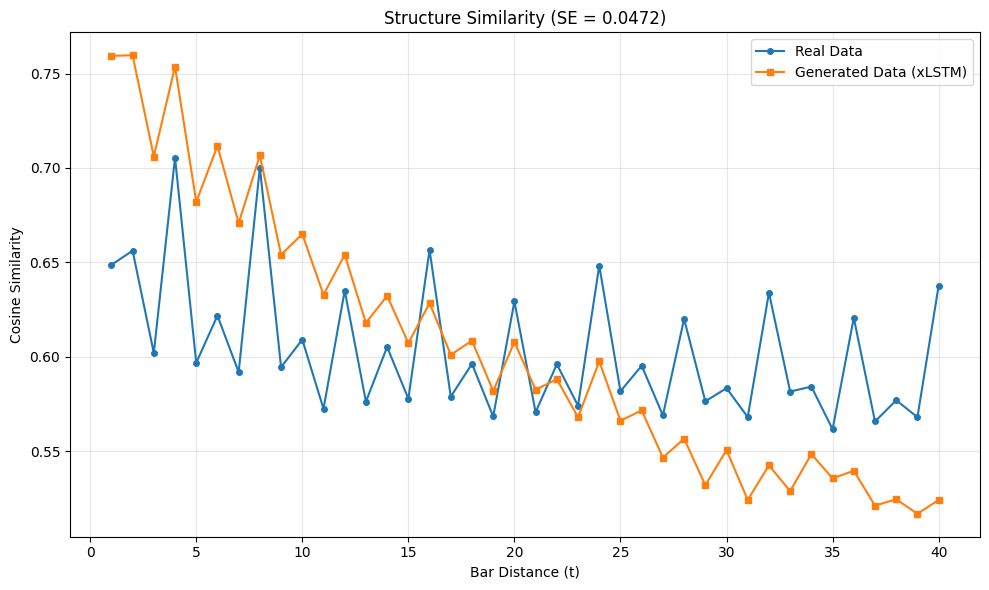

In [8]:
plt.figure(figsize=(10, 6))
x_axis = np.arange(1, len(L_real) + 1)

plt.plot(x_axis, L_real, label='Real Data', marker='o', markersize=4)
plt.plot(x_axis, L_gen, label='Generated Data (xLSTM)', marker='s', markersize=4)

plt.xlabel("Bar Distance (t)")
plt.ylabel("Cosine Similarity")
plt.title(f"Structure Similarity (SE = {se_score:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Results

In [9]:
results = {
    "SE": float(se_score),
    "model_checkpoint": GEN_DIR.name,
    "config": {
        "T_BARS": T_BARS,
        "MAX_BARS": MAX_BARS
    },
    "paths": {
        "real_dir": str(MIDI_DATA_DIR),
        "valid_split": str(VALID_SPLIT_FILE),
        "gen_dir": str(GEN_DIR)
    },
    "L_real": L_real.tolist(),
    "L_gen": L_gen.tolist()
}

try:
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    with open(OUTPUT_FILE, "w") as f:
        json.dump(results, f, indent=4)
    print(f"Results saved to {OUTPUT_FILE}")
except Exception as e:
    print(f"Could not save results to {OUTPUT_FILE}: {e}")
    print("Results dictionary:")
    print(json.dumps(results, indent=2))

Results saved to /scratch1/e20-fyp-xlstm-music-generation/e20fyptemp1/fyp-musicgen/evaluation/se_results_xlstm_84000.json
